<a href="https://colab.research.google.com/github/Nermen-Salama/PhD_practice/blob/toto2.0_313B/toto2_0_313B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
!pip install toto-models

  Using cached toto_models-1.0.0-py3-none-any.whl.metadata (2.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 17.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 20.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 119.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.7 MB/s  0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.2
    Uninstalling packaging-26.2:
      Successfully uninstalled packaging-26.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [toto-models]


In [ ]:
import torch
from toto2 import Toto2Model

model = Toto2Model.from_pretrained("Datadog/Toto-2.0-313m")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()

# (batch, n_variates, time_steps)
target = torch.randn(1, 1, 512, device=device)
target_mask = torch.ones_like(target, dtype=torch.bool)
series_ids = torch.zeros(1, 1, dtype=torch.long, device=device)

# Returns quantiles of shape (9, batch, n_variates, horizon)
# Quantile levels: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
quantiles = model.forecast(
    {"target": target, "target_mask": target_mask, "series_ids": series_ids},
    horizon=96,
    decode_block_size=768,
    has_missing_values=False,
)


config.json:   0%|          | 0.00/598 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.25G [00:00<?, ?B/s]

In [ ]:

import torch
from toto2 import Toto2Model

SIZE = "313m"  # 4m | 22m | 313m | 1B | 2.5B
CHECKPOINT = f"Datadog/Toto-2.0-{SIZE}"

device = "cuda" if torch.cuda.is_available() else "cpu"
model = Toto2Model.from_pretrained(CHECKPOINT, map_location=device)
model = model.to(device).eval()

print(f"Loaded {CHECKPOINT}: {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Patch size: {model.config.patch_size}")

Loaded Datadog/Toto-2.0-313m: 312,684,608 parameters
Patch size: 32


In [ ]:

# Synthetic univariate series: trend + seasonality + noise
context_length = 512
t = torch.arange(context_length, dtype=torch.float32)
series = 100 + 0.05 * t + 10 * torch.sin(2 * torch.pi * t / 24) + torch.randn(context_length)

# Shape: (batch=1, n_var=1, time)
target = series.unsqueeze(0).unsqueeze(0).to(device)
target_mask = torch.ones_like(target, dtype=torch.bool)
series_ids = torch.zeros(1, 1, dtype=torch.long, device=device)

horizon = 96
quantiles = model.forecast(
    {"target": target, "target_mask": target_mask, "series_ids": series_ids},
    horizon=horizon,
)

print(f"Output shape: {quantiles.shape}")  # (9, 1, 1, 96)
print(f"Quantile levels: {model.output_head.knots}")


Output shape: torch.Size([9, 1, 1, 96])
Quantile levels: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


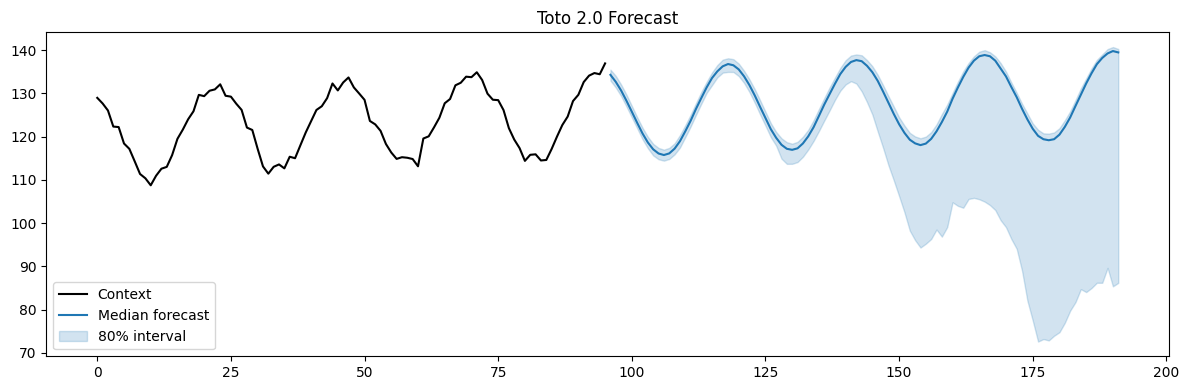

In [ ]:

import matplotlib.pyplot as plt

median = quantiles[4, 0, 0].cpu()  # 0.5 quantile
q10 = quantiles[0, 0, 0].cpu()     # 0.1 quantile
q90 = quantiles[8, 0, 0].cpu()     # 0.9 quantile

fig, ax = plt.subplots(figsize=(12, 4))
ctx = series[-96:].cpu()
ax.plot(range(96), ctx, label="Context", color="black")
ax.plot(range(96, 96 + horizon), median, label="Median forecast", color="tab:blue")
ax.fill_between(range(96, 96 + horizon), q10, q90, alpha=0.2, color="tab:blue", label="80% interval")
ax.legend()
ax.set_title("Toto 2.0 Forecast")
plt.tight_layout()
plt.show()


In [ ]:

n_var = 3
target_mv = torch.randn(1, n_var, 512, device=device)
mask_mv = torch.ones(1, n_var, 512, dtype=torch.bool, device=device)
ids_mv = torch.zeros(1, n_var, dtype=torch.long, device=device)

quantiles_mv = model.forecast(
    {"target": target_mv, "target_mask": mask_mv, "series_ids": ids_mv},
    horizon=48,
)
print(f"Multivariate output: {quantiles_mv.shape}")  # (9, 1, 3, 48)

Multivariate output: torch.Size([9, 1, 3, 48])


In [ ]:

target_missing = series.unsqueeze(0).unsqueeze(0).to(device)
mask_missing = torch.ones_like(target_missing, dtype=torch.bool)
# Drop 20% of observations at random
mask_missing[0, 0, torch.randperm(context_length)[:context_length // 5]] = False

quantiles_missing = model.forecast(
    {
        "target": target_missing,
        "target_mask": mask_missing,
        "series_ids": torch.zeros(1, 1, dtype=torch.long, device=device),
    },
    horizon=96,
)
print(f"With missing values: {quantiles_missing.shape}")

With missing values: torch.Size([9, 1, 1, 96])
